In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importar librerías a utilizar para crear el modelo

In [60]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

Importamos herramientas de Sklearn para crear el modelo

In [ ]:
data = pd.read_csv('diamonds.csv')

Importamos el dataset

In [ ]:
print(data.head())
print(data.info())
print(data.describe())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53939 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53939 non-null  float64
 8   y        53940 non-null  float64
 9   z        53930 non-null  float64
dtypes: f

Información básica del dataset

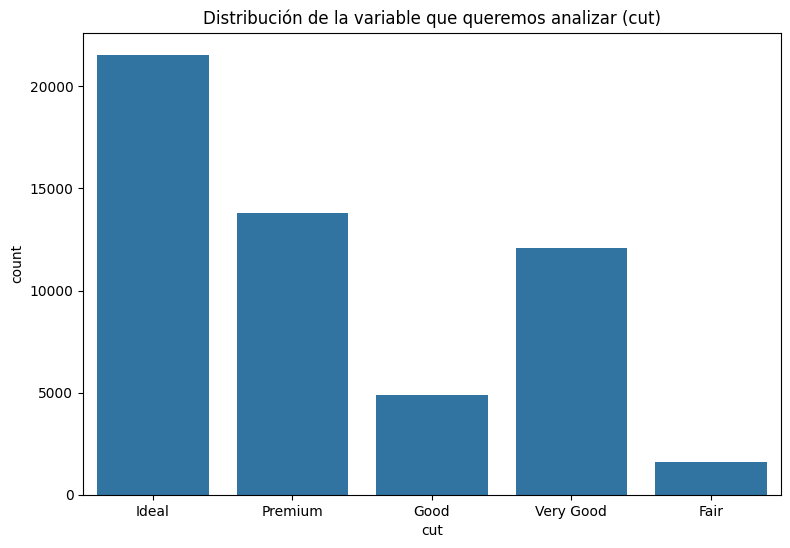

In [ ]:
plt.figure(figsize=(9, 6))
sns.countplot(x='cut', data=data)
plt.title('Distribución de la variable que queremos analizar (cut)')
plt.show()

Visualizo gráficamente la distribución de los diamanetes y los cortes


In [ ]:
print(data.isnull().sum())

carat       0
cut         0
color       0
clarity     0
depth       1
table       0
price       0
x           1
y           0
z          10
dtype: int64


Compruebo que no hayan valores nulos. En este caso los hay.

In [ ]:
data_cleaned = data.dropna()

Limpio los nulos

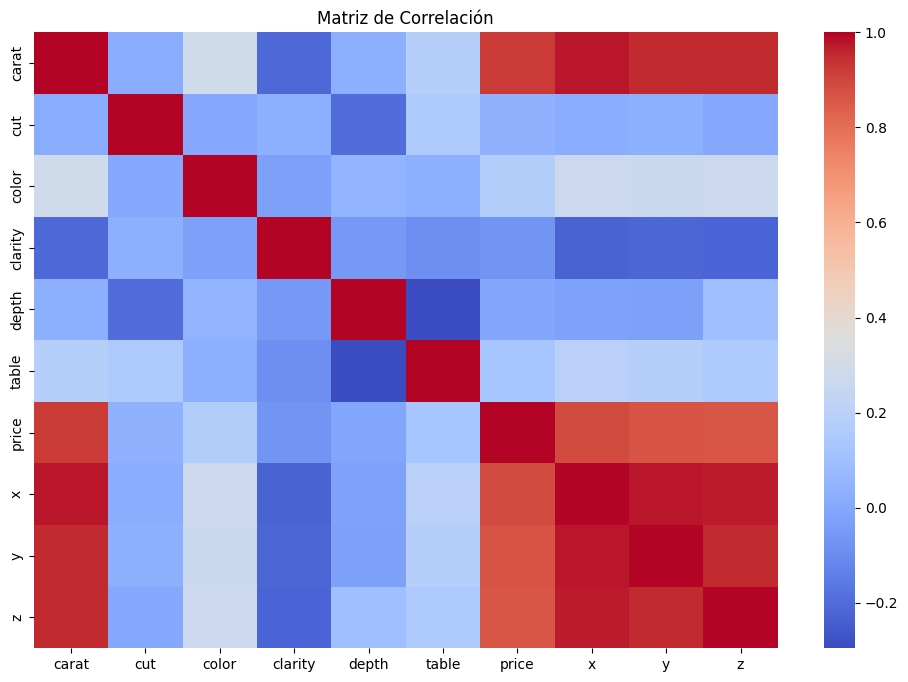

In [16]:
data_dummies = pd.get_dummies(data_cleaned)

df_corr = data_dummies.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=False, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

Transformamos los valores no numéricos a valores utilizables para el modelo con el método de get dummies(TRUE, FALSE) y grafico la matriz de corelación.

In [17]:
scaler = StandardScaler()
numerical_columns = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
data_dummies[numerical_columns] = scaler.fit_transform(data_dummies[numerical_columns])

Utilizo el Scaler para normalizar los datos numéricos teniendo en cuenta el tamaño del dataset

In [26]:
X = data_dummies.drop('cut', axis=1)
y = data_dummies['cut']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Creamos las variables X e y para las pruebas

In [52]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classifier:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))

Random Forest Classifier:
MAE: 0.35119599480808456
MSE: 0.6871870943816057
R²: 0.34490213712503914


El primer modelo que creo es el de Random Forecast con su correspondiente exactitud medida a través del mean absolute error, mean squared error y R2

In [54]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("K-Neighbors Classifier:")
print("MAE:", mean_absolute_error(y_test, y_pred_knn))
print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("R²:", r2_score(y_test, y_pred_knn))

K-Neighbors Classifier:
MAE: 0.535601705915075
MSE: 1.0308733543482291
R²: 0.017264822273787117


El segundo es el KNeighborsClassifier, que como se ve, ha dado una exactitud mas baja que el primer modelo.

In [53]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Classifier:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R²:", r2_score(y_test, y_pred_dt))

Decision Tree Classifier:
MAE: 0.48794733914333394
MSE: 0.9752456888559243
R²: 0.07029487053673589


El tercer modelo es con DecisionTreeClassifier, en el cual vemos que hay una exactitud incluso menor a la del primer modelo pero mayor a la del segundo.

In [56]:
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
1349/1349 [==============================] - 15s 8ms/step - loss: 3.4804 - accuracy: 0.0927 - val_loss: 3.4710 - val_accuracy: 0.0836
Epoch 2/50
1349/1349 [==============================] - 4s 3ms/step - loss: 3.4677 - accuracy: 0.0927 - val_loss: 3.4710 - val_accuracy: 0.0836
Epoch 3/50
1349/1349 [==============================] - 6s 4ms/step - loss: 3.4677 - accuracy: 0.0927 - val_loss: 3.4710 - val_accuracy: 0.0836
Epoch 4/50
1349/1349 [==============================] - 4s 3ms/step - loss: 3.4677 - accuracy: 0.0927 - val_loss: 3.4710 - val_accuracy: 0.0836
Epoch 5/50
1349/1349 [==============================] - 4s 3ms/step - loss: 3.4677 - accuracy: 0.0927 - val_loss: 3.4710 - val_accuracy: 0.0836
Epoch 6/50
1349/1349 [==============================] - 5s 4ms/step - loss: 3.4677 - accuracy: 0.0927 - val_loss: 3.4710 - val_accuracy: 0.0836
Epoch 7/50
1349/1349 [==============================] - 4s 3ms/step - loss: 3.4677 - accuracy: 0.0927 - val_loss: 3.4710 - val_accuracy

Creamos una red neuronal con Keras

In [58]:
y_pred_nn = model.predict(X_test)
y_pred_nn_classes = (y_pred_nn > 0.5).astype(int).flatten()

print("Neural Network con keras:")
print("MAE:", mean_absolute_error(y_test, y_pred_nn_classes))
print("MSE:", mean_squared_error(y_test, y_pred_nn_classes))
print("R²:", r2_score(y_test, y_pred_nn_classes))

338/338 [==============================] - 2s 5ms/step
Neural Network con keras:
MAE: 1.6182087891711479
MSE: 3.470980901168181
R²: -2.3088982447804622


Finalmente evaluamos los resultados de la red neuronal, los cuales son considerablemente menos exactos que los modelos previamente utilizados.

            Model       MAE       MSE        R²
0   Random Forest  0.351196  0.687187  0.344902
1     K-Neighbors  0.535602  1.030873  0.017265
2   Decision Tree  0.487947  0.975246  0.070295
3  Neural Network  1.618209  3.470981 -2.308898


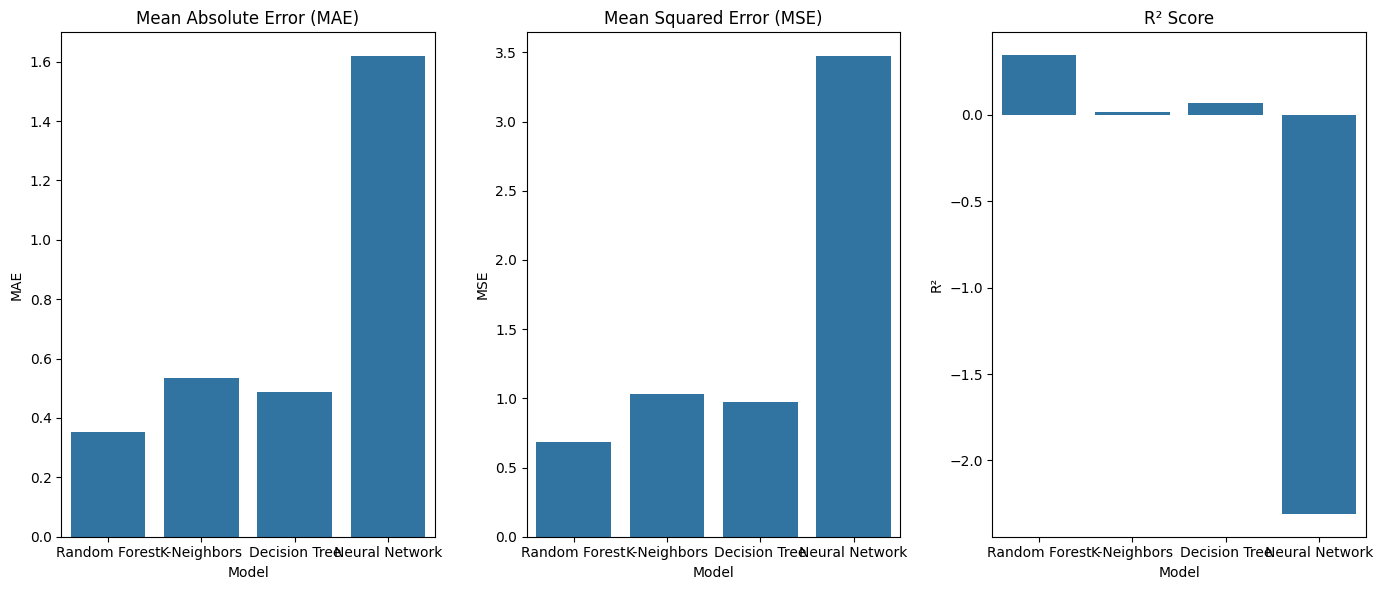

In [62]:
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'K-Neighbors', 'Decision Tree', 'Neural Network'],
    'MAE': [mean_absolute_error(y_test, y_pred_rf), mean_absolute_error(y_test, y_pred_knn), mean_absolute_error(y_test, y_pred_dt), mean_absolute_error(y_test, y_pred_nn_classes)],
    'MSE': [mean_squared_error(y_test, y_pred_rf), mean_squared_error(y_test, y_pred_knn), mean_squared_error(y_test, y_pred_dt), mean_squared_error(y_test, y_pred_nn_classes)],
    'R²': [r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_knn), r2_score(y_test, y_pred_dt), r2_score(y_test, y_pred_nn_classes)]
})

print(results_df)

plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='MAE', data=results_df)
plt.title('Mean Absolute Error (MAE)')

plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='MSE', data=results_df)
plt.title('Mean Squared Error (MSE)')

plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='R²', data=results_df)
plt.title('R² Score')

plt.tight_layout()
plt.show()


Por último, muestro los resultados de los cuatro modelos utilizados creando un dataframe nuevo. y mostrando también una tabla con los resultados.